
# Lab Assignment 16: Great British Bake Off (A/B Test)

This week's lab will focus on A/B Testing using data from the ever-popular British television show, [*The Great British Bake Off*](https://en.wikipedia.org/wiki/The_Great_British_Bake_Off).

#### **Helpful Resource:**
- [Python Reference](http://data8.org/sp24/reference/)

**Recommended Readings:**

* [Error Probabilities](https://inferentialthinking.com/chapters/11/4/Error_Probabilities.html)
* [A/B Testing](https://inferentialthinking.com/chapters/12/1/AB_Testing.html)

In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
#warnings.simplefilter('ignore', (FutureWarning, np.VisibleDeprecationWarning))


## 1. A/B Testing

A/B testing is a form of hypothesis testing that allows you to make comparisons between two distributions. We may also refer to an A/B test as a permutation test.

You'll almost never be explicitly asked to perform an A/B test. Make sure you can identify situations where the test is appropriate and know how to correctly implement each step. Oftentimes, we use an A/B test to determine whether or not two samples came from the same underlying distribution.

**Question 1.1.** The following statements are the steps of an A/B hypothesis test presented in a *random order*:

1. Choose a test statistic (typically the difference in means between two categories)

2. Shuffle the labels of the original sample, find your simulated test statistic, and repeat many times

3. Find the value of the observed test statistic

4. Calculate the p-value based off your observed and simulated test statistics

5. Define a null and alternate model

6. Use the p-value and p-value cutoff to draw a conclusion about the null hypothesis

Assign `ab_test_order` to an array of integers that contains the correct order of an A/B test, where the first item of the array is the first step of an A/B test and the last item of the array is the last step of an A/B test.


In [ ]:
ab_test_order = make_array(5, 1, 3, 2, 4, 6)

**Question 1.2.** If the null hypothesis of an A/B test is correct, should the order of labels affect the differences in means between each group? Why do we shuffle labels in an A/B test? If you are in a lab section, confirm your answer with a neighbor or staff member before moving on.


If the null hypothesis of an A/B test is true that is, if the distributions of the two groups are identical the order of the labels should not affect the difference in the means between the two groups.

The reason labels are shuffled in an A/B test is to simulate the distribution of the test statistic that would be obtained if the null hypothesis were true. By randomly reassigning labels, we can assess whether the observed mean difference is due to chance or whether there is a real difference between the two groups. This is used to calculate the p-value by generating a distribution under the null hypothesis.

## 2. The Great British Bake Off

>"The Great British Bake Off (often abbreviated to Bake Off or GBBO) is a British television baking competition, produced by Love Productions, in which a group of amateur bakers compete against each other in a series of rounds, attempting to impress a group of judges with their baking skills" [Wikipedia](https://en.wikipedia.org/wiki/The_Great_British_Bake_Off)

For every week of the competition, the judges assign one contestant the title "Star Baker". Ultimately, one winner is crowned every season. Using this information, we would like to investigate how winning Star Baker awards affects the odds of winning a season of the show.

**Question 2.1.** We want to know whether winning more Star Baker awards ___causes___ a change in likelihood of winning the season.  Why is it not sufficient to compare star baker rates for winners and losers?


Simply comparing the Star Baker award rates between winners and non-winners does not allow us to conclude that winning the Star Baker award causes the likelihood of winning the season. This is because correlation does not imply causation. Other factors may influence the relationship between winning the Star Baker award and winning the season, and these factors may influence both (confounding variables). For example, superior baking skills or editing effects may influence both outcomes. Asserting causality requires a more rigorous research design, such as a randomized controlled experiment, which has limitations based solely on observational data.

### Running an Experiment

We are going to run the following hypothesis test to determine the association between winning and number of Star Baker awards. The population we are examining is every contestant from seasons 2 through 11 of GBBO. We are going to use the following null and alternative hypotheses:

**Null hypothesis:** The distribution of Star Baker awards between contestants who won their season and contestants who did not win their season is the same.

**Alternative hypothesis:** Contestants who win their season of the show will win more Star Baker awards on average.

Our alternative hypothesis is related to our suspicion that contestants who win more Star Baker awards are more skilled, so they are more likely to win the season.

**Question 2.2.** Should we use an A/B test to test these hypotheses? If yes, what is our "A" group and what is our "B" group?


Yes, it would be appropriate to use A/B testing to test these hypotheses.

Group A: Contestants who did not win the season (won == 0)
Group B: Contestants who won the season (won == 1)
We want to determine whether there is a difference in the distribution of Star Baker awards between the two groups (winners and non-winners), specifically whether winners receive more Star Baker awards on average than non-winners.

Check your answers with your neighbors or a staff member before you move on to the next section.

The `bakers` table below describes the number of star baker awards each contest won and whether or not they won their season (`1` if they won, `0` if they did not win). The data was manually aggregated from Wikipedia for seasons 2-11 of the show. We randomized the order of rows as to not spoil the outcome of the show.

In [4]:
bakers = Table.read_table("./DS/star_bakers.csv")
bakers.show(3)

star baker awards,won
3,1
0,0
1,0


**Question 2.3.** Create a new table called `means` that contains the mean number of star baker awards for bakers who did not win (`won==0`) and bakers that did win (`won==1`). The table should have the column names `won` and `star baker awards mean`.

In [5]:
means = bakers.group('won', np.mean).select('won', 'star baker awards mean')
means

won,star baker awards mean
0,0.651786
1,1.5


**Question 2.4.** Visualize the distribution of Star Baker awards for winners and non-winners as overlaid histograms. You should use the bins we provided.

Hint: You will want to use the group argument of `tbl.hist`. In order to produce several overlayed histograms based on unique values in a given column, we can do something like `tbl.hist(..., group=<col_name>, bins=...)`. This will graph one histogram for each unique value in the specified column all on a single plot.


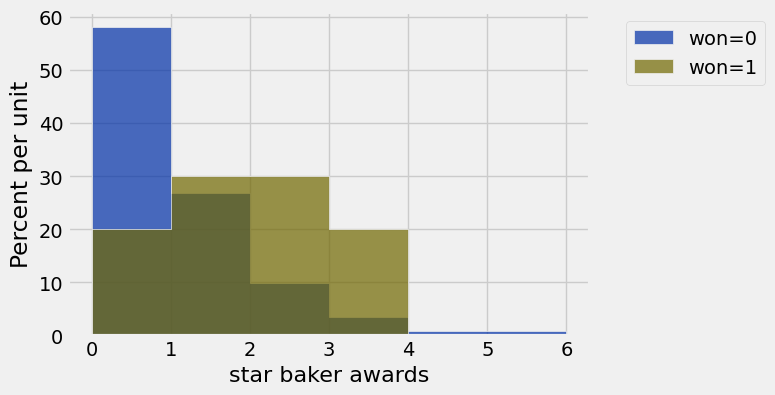

In [7]:
useful_bins = np.arange(0, 7)
bakers.hist('star baker awards', group='won', bins=useful_bins)

**Question 2.5.** We want to figure out if there is a difference between the distribution of Star Baker awards between winners and non winners.

What should the test statistic be? Which values of this test statistic support the null, and which values support the alternative? **Assign `test_option` to the number corresponding to the correct test statistic.**

1. Absolute value of the difference between the means between both groups; high values support the null
2. Absolute value of the difference between the means between both groups; low values support the null
3. Average Star Baker awards for winners - average Star Baker awards for non-winners; high values support the null
4. Average Star Baker awards for winners - average Star Baker awards for non-winners; low values support the null

Before moving on, confirm your answer with a peer or in the discussion forums.

_Hint:_ You should think about what measures we use to describe a distribution.


In [9]:
test_option = 4

**Question 2.6.** Set `observed_difference` to the observed test statistic using the `means` table.


In [10]:
observed_difference = means.where('won', 1).column('star baker awards mean').item(0) - means.where('won', 0).column('star baker awards mean').item(0)
observed_difference

0.8482142857142857

**Question 2.7.** Given a table like `bakers`, a label column `label_col`, and a values column `val_col`, write a function that calculates the appropriate test statistic.

*Hint:* Make sure that you are taking the directionality of our alternative hypothesis into account.


In [13]:
def find_test_stat(tbl, label_col, val_col):
    means = tbl.group(label_col, np.mean).select(label_col, f'{val_col} mean')
    mean_winner = means.where(label_col, 1).column(f'{val_col} mean').item(0)
    mean_non_winner = means.where(label_col, 0).column(f'{val_col} mean').item(0)
    return mean_winner - mean_non_winner

find_test_stat(bakers, "won", "star baker awards")

0.8482142857142857

When we run a simulation for A/B testing, we resample by **shuffling the labels** of the original sample. If the null hypothesis is true and the star baker award distributions are the same, we expect that the difference in mean star baker awards to not change when `"won"` labels are changed.

**Question 2.8.** Write a function `simulate_and_test_statistic` to compute one trial of our A/B test. Your function should run a simulation and return a test statistic.


In [15]:
def simulate_and_test_statistic(tbl, labels_col, values_col):
    shuffled_labels = tbl.sample(with_replacement=False).column(labels_col)
    shuffled_table = tbl.drop(labels_col).with_column(labels_col, shuffled_labels)

    return find_test_stat(shuffled_table, labels_col, values_col)

simulate_and_test_statistic(bakers, "won", "star baker awards")

-0.023214285714285743

**Question 2.9.** Simulate 5000 trials of our A/B test and store the test statistics in an array called `differences`.


In [16]:
# This cell might take a couple seconds to run
differences = make_array()

num_simulations = 5000

for _ in range(num_simulations):
    sim_stat = simulate_and_test_statistic(bakers, "won", "star baker awards")
    differences = np.append(differences, sim_stat)

differences

array([-0.13214286,  0.52142857, -0.13214286, ..., -0.02321429,
       -0.56785714, -0.35      ])

Run the cell below to view a histogram of your simulated test statistics plotted with your observed test statistic.

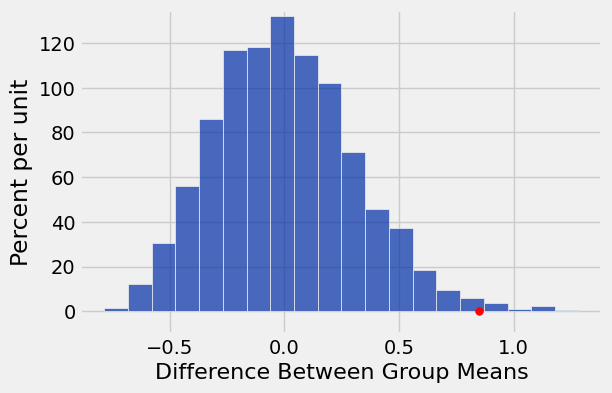

In [17]:
Table().with_column('Difference Between Group Means', differences).hist(bins=20)
plots.scatter(observed_difference, 0, color='red', s=30, zorder=2)
plots.ylim(-0.1, 1.35);

**Question 2.10.** Find the p-value for your test and assign it to `empirical_p`.


In [19]:
empirical_p = np.count_nonzero(differences >= observed_difference) / num_simulations
empirical_p

0.0142

**Question 2.11.** Using a 5% P-value cutoff, draw a conclusion about the null and alternative hypotheses. Describe your findings using simple, non-technical language. What does your analysis tell you about the association between star baker awards and winning? What can you claim about causation from your statistical analysis? Confirm your answer with a peer, instructor or in the discussion forums.


The calculated empirical p-value is 0.0142, and the significance level (p-value cutoff) is 5% (0.05). Because the p-value (0.0142) is less than the significance level (0.05), we reject the null hypothesis.

This means there is insufficient evidence to support the null hypothesis that the distribution of Star Baker awards is identical between season winners and non-winners. Instead, we found evidence supporting the alternative hypothesis that season winners, on average, receive more Star Baker awards.

In short, our analysis shows that contestants who win a season of The Great British Bake Off tend to receive more Star Baker awards than non-winners.

While this statistical analysis demonstrates a correlation between Star Baker awards and season wins, it cannot directly assert that Star Baker awards cause season wins. This is because, as discussed in Question 2.1, it is difficult to establish causality based on observational data alone. Contestants who win more Star Baker awards are more likely to already possess exceptional baking skills, and this exceptional skill may contribute to both winning the Star Baker award and winning the season. Therefore, our analysis demonstrates a correlation, but does not prove causation.

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [20]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab16(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab16(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab16(SSU)_files/
[NbConvertApp] Making directory ./lab16(SSU)_files
[NbConvertApp] Writing 76508 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 125703 bytes to DS/lab16(SSU).pdf
